**About The Assignment** <br>
We have chosen English-Hindi parellel corpus. <br>
Here we will be doing the **Part 1** of the assignment.

**Imports**<br>
Import required packages


In [62]:
import math
import matplotlib.pyplot as plt
import statistics
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [63]:
file1 = open("final_outcomes\clean_en.txt","r",encoding="utf-8")
file2 = open("final_outcomes\clean_hi.txt","r",encoding="utf-8")

## **Calculate frequency of characters** ##
First create dictionaries to store the character vs count data.

Let us find the characters used and their count.

In [64]:
en_char_dict = dict()
hi_char_dict = dict()

### **English corpus** ###
Iterate through file and add each unique word to **en_char_dict** dictionary as key and the frequency of the word as value.

In [65]:
for x in file1:
  for character in x:
    if character in en_char_dict:
      en_char_dict[str(character)] += 1
    else :
      en_char_dict[str(character)] = 1
file1.seek(0)

0

### **Hindi corpus** ###
Iterate through file and add each unique word to **hi_char_dict** dictionary as key and the frequency of the word as value.

In [66]:
for x in file2:
  for character in x:
    if character in hi_char_dict:
      hi_char_dict[str(character)] += 1
    else :
      hi_char_dict[str(character)] = 1
file2.seek(0)

0

## **Character Level Language Model and Next Character Prediction** ##

Steps to create an LM for predicting next word:
1. Preprocess corpus data.
2. Map the characters to Numeric values.
3. Get the N-grams representation for the Numeric vectors.
4. Input output split.
5. One-hot encoding for output.
6. Model creation and Training.
7. Prediction.

### **English Corpus** ###
Store the corpus in a list. Each entry of the list has one line from corpus. Let us try with first 100 lines.

**Preprocessing** :

In [67]:
en_char_corpus_list = []

In [68]:
count = 0
for x in file1:
  en_char_corpus_list.append(x.strip())
  count += 1
  if(count == 100):
    break
file1.seek(0)

0

In [ ]:
print(en_char_corpus_list[:10])

**Map the Characters to Numeric values :** <br>

In the beginning we have created **en_char_dict** which has unique characters in the english corpus as keys. So let's use that for mapping.

In [70]:
en_char_to_index = {u: i for i, u in enumerate(en_char_dict.keys())}
en_index_to_char = {i: u for i, u in enumerate(en_char_dict.keys())}
en_char_vocab_size = len(en_char_dict) #number of unique characters

Now we will replace each character in the corpus with its corresponding numeric value and store it in **en_char_corpus_list_as_numeric**.

In [71]:
en_char_corpus_list_as_numeric = []

for x in en_char_corpus_list:         #get line by line
  temp_list = []
  for a in x:
    temp_list.append(en_char_to_index[str(a)])
  en_char_corpus_list_as_numeric.append(temp_list) #append numeric line

In [72]:
print(en_char_corpus_list_as_numeric[0])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 4, 9, 10, 11, 12, 3, 1, 13, 8, 8, 3, 6, 11, 3, 14, 15, 2, 16, 13, 17, 11, 17, 3, 13, 9, 3, 11, 4, 10, 18, 3, 2, 19, 3, 20, 18, 11, 12, 11, 3, 14, 8, 4, 10, 11, 12, 21]


**N-gram Representation** : <br>
Here we will take each entry of **en_char_corpus_list_as_numeric** and get its n-gram representation.

Ex: if we have an entry of length 5 ->[10,20,30,40,50], we will get 4 lists from this entry to get the relationships between the characters. The 4 lists are : <br>

1. [10,20] -> relationship between 10 and 20
2. [10,20,30] -> relationship between [10,20] and 30
3. [10,20,30,40] -> relationship between [10,20,30] and 40
4. [10,20,30,40,50] -> relationship between [10,20,30,40] and 50

In [13]:
'''ln = [10,20,30,40,50]
for i in range(1,len(ln)):
    print(ln[:i+1])'''

'ln = [10,20,30,40,50]\nfor i in range(1,len(ln)):\n    print(ln[:i+1])'

Let us take 2,3,4,5 grams only

In [14]:
#in a single round all grams
''''en_char_training_sequences = []
for line in en_char_corpus_list_as_numeric:
    for i in range(1, min(len(line), 7)):  # Adjusted the upper bound to ensure maximum 6-grams
        n_char_gram_sequence = line[:i+1]
        if len(n_char_gram_sequence) >= 2:  # Ensure minimum 2-grams
            en_char_training_sequences.append(n_char_gram_sequence)'''


"'en_char_training_sequences = []\nfor line in en_char_corpus_list_as_numeric:\n    for i in range(1, min(len(line), 7)):  # Adjusted the upper bound to ensure maximum 6-grams\n        n_char_gram_sequence = line[:i+1]\n        if len(n_char_gram_sequence) >= 2:  # Ensure minimum 2-grams\n            en_char_training_sequences.append(n_char_gram_sequence)"

In [15]:
'''en_char_training_sequences = []
for line in en_char_corpus_list_as_numeric:
  for i in range(1,len(line)):
    n_char_gram_sequence = line[:i+1]
    en_char_training_sequences.append(n_char_gram_sequence)'''

'en_char_training_sequences = []\nfor line in en_char_corpus_list_as_numeric:\n  for i in range(1,len(line)):\n    n_char_gram_sequence = line[:i+1]\n    en_char_training_sequences.append(n_char_gram_sequence)'

In [73]:
#different for loops for different grams
en_char_training_sequences = []

# Generate 2-grams
for line in en_char_corpus_list_as_numeric:
    for i in range(len(line) - 1):
        n_char_gram_sequence = line[i:i+2]
        en_char_training_sequences.append(n_char_gram_sequence)


In [74]:
print(len(en_char_training_sequences),en_char_training_sequences[0])

7437 [0, 1]


In [75]:
# Generate 3-grams
for line in en_char_corpus_list_as_numeric:
    for i in range(len(line) - 2):
        n_char_gram_sequence = line[i:i+3]
        en_char_training_sequences.append(n_char_gram_sequence)

In [76]:
print(len(en_char_training_sequences),en_char_training_sequences[-1])

14774 [11, 12, 21]


In [78]:
# Generate 4-grams
for line in en_char_corpus_list_as_numeric:
    for i in range(len(line) - 3):
        n_char_gram_sequence = line[i:i+4]
        en_char_training_sequences.append(n_char_gram_sequence)

In [79]:
print(len(en_char_training_sequences),en_char_training_sequences[-1])

22011 [8, 11, 12, 21]


In [80]:
# Generate 5-grams
for line in en_char_corpus_list_as_numeric:
    for i in range(len(line) - 4):
        n_char_gram_sequence = line[i:i+5]
        en_char_training_sequences.append(n_char_gram_sequence)


In [81]:
print(len(en_char_training_sequences),en_char_training_sequences[-1])

29148 [29, 8, 11, 12, 21]


In [82]:
# Generate 6-grams
for line in en_char_corpus_list_as_numeric:
    for i in range(len(line) - 5):
        n_char_gram_sequence = line[i:i+6]
        en_char_training_sequences.append(n_char_gram_sequence)

In [83]:
print(len(en_char_training_sequences),en_char_training_sequences[-1])

36185 [9, 29, 8, 11, 12, 21]


**Padding** : <br>
Neural networks take fixed length of input. To maintain the fixed length we will do pre-padding so that all the entries will be of same length (i.e. maximum length <we have calculated erlier>).

In [84]:
max_len_en = 6
en_char_training_sequences = np.array(pad_sequences(en_char_training_sequences,maxlen=max_len_en,padding='pre'))

**Input-output Split**

In [85]:
en_char_input = en_char_training_sequences[:,:-1]
en_char_output = en_char_training_sequences[:,-1]

**One-hot encoding**

In [86]:
en_char_output = tf.keras.utils.to_categorical(en_char_output,num_classes=en_char_vocab_size)

**Model creation**

In [87]:
model_en_char = tf.keras.Sequential([
    tf.keras.layers.Embedding(en_char_vocab_size, 64, input_length=max_len_en-1),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20)),
    tf.keras.layers.Dense(en_char_vocab_size, activation='softmax')
])

model_en_char.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 5, 64)             5824      
                                                                 
 bidirectional_2 (Bidirecti  (None, 40)                13600     
 onal)                                                           
                                                                 
 dense_2 (Dense)             (None, 91)                3731      
                                                                 
Total params: 23155 (90.45 KB)
Trainable params: 23155 (90.45 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [88]:
model_en_char.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

**Model Training**

In [89]:
history_en_char = model_en_char.fit(en_char_input, en_char_output, epochs=50, verbose=1)

Epoch 1/50


1131/1131 [==============================] - 7s 4ms/step - loss: 2.8931 - accuracy: 0.2182
Epoch 2/50
1131/1131 [==============================] - 5s 4ms/step - loss: 2.5413 - accuracy: 0.2812
Epoch 3/50
1131/1131 [==============================] - 5s 4ms/step - loss: 2.4519 - accuracy: 0.2933
Epoch 4/50
1131/1131 [==============================] - 5s 5ms/step - loss: 2.3914 - accuracy: 0.3053
Epoch 5/50
1131/1131 [==============================] - 5s 5ms/step - loss: 2.3451 - accuracy: 0.3170
Epoch 6/50
1131/1131 [==============================] - 5s 5ms/step - loss: 2.3063 - accuracy: 0.3302
Epoch 7/50
1131/1131 [==============================] - 5s 5ms/step - loss: 2.2751 - accuracy: 0.3382
Epoch 8/50
1131/1131 [==============================] - 5s 5ms/step - loss: 2.2464 - accuracy: 0.3466
Epoch 9/50
1131/1131 [==============================] - 5s 5ms/step - loss: 2.2212 - accuracy: 0.3500
Epoch 10/50
1131/1131 [==============================] - 5s 5ms/step - loss: 2.1995 - accurac

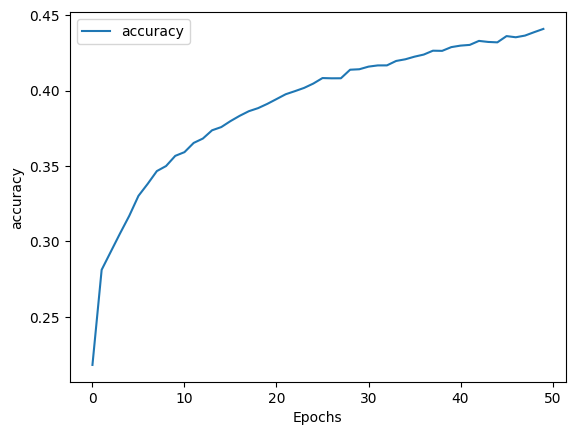

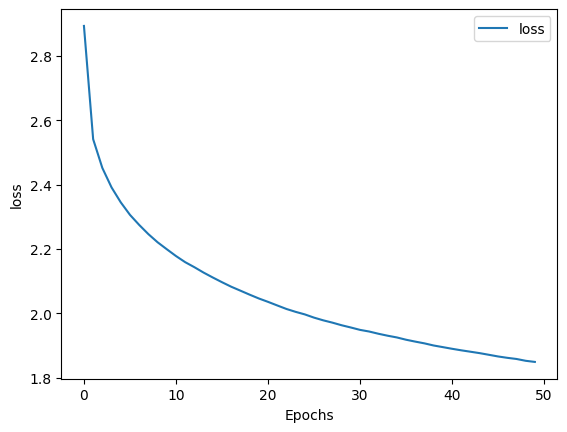

In [91]:
# Plot utility
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

# Plot the accuracy and results
plot_graphs(history_en_char, "accuracy")
plot_graphs(history_en_char, "loss")

In [ ]:
#save the model
model_en_char.save('en_char_prediction')

In [93]:
#load and predict the next word
loaded_en_char_model = tf.keras.models.load_model('en_char_prediction')


**next char prediction**

In [94]:
#predict the next 10 chars
test_text = "Ki"
test_tokens = []

for x in test_text:                                   #numeric conversion
  test_tokens.append(en_char_to_index[x])

test_tokens = pad_sequences([test_tokens],maxlen=max_len_en-1,padding='pre')  #padding to adjust length

for i in range(10):
  probabilities = loaded_en_char_model.predict(test_tokens)
  predicted = np.argmax(probabilities,axis = -1)[0]
  output_char = en_index_to_char[predicted]
  test_text = test_text + output_char

  test_tokens = np.append(test_tokens, [[predicted]], axis=1)
  test_tokens = test_tokens[:,1:]

print(test_text)

1/1 [==============================] - 0s 29ms/step
Kise and as 


### **Hindi Corpus** ###
Repeat the same process for Hindi corpus.

**Preprocessing**

In [107]:
hi_char_corpus_list = []

In [108]:
count = 0
for x in file2:
  hi_char_corpus_list.append(x.strip())
  count += 1
  if(count == 100):
    break
file2.seek(0)

0

In [109]:
print(hi_char_corpus_list)

['इसके लिए प्रत्येक थाने में दोदो गाडि़यां उपलब्ध कराई जाएंगी।', 'न्यूजीलैंड को पाकिस्तान और आस्ट्रेलिया के खिलाफ पिछले दो मुकाबलों में हार का सामना करना पड़ा है', 'में कुछु देर बाद बेहोश हो गई।', 'भारत दुनिया में पहला बड़ा देश होगा जो उस पैमाने के बारे में सोचता है।', 'देसाई ने कहा  इन लड़कों आर्यन और मर्चेंट को अगर समानता के आधार पर नहीं तो स्वतंत्रता के आधार पर जमानत दी जानी चाहिएसख्त शर्तों के आधार पर इन्हें जमानत पर रिहा करें।', 'अभी अनुमति नहीं मिली है।', 'इस दौरान यहां कड़ी सुरक्षा भी रही।', 'वहीं राधिका मदान इरफान की टीनएज बेटी का रोल प्ले करेंगी।', 'देश में गरीबी रेखा से नीचे जीवनयापन करने वाले लोगों की बड़ी संख्या है', 'अरुणाचल प्रदेश और मिजोरम में बारिश से हुए हादसों में दोदो लोगों ने अपनी जान गंवाई।', 'और यह बहुत दुर्लभ भी है', 'इससे रोजगार के नये अवसर भी बनेंगे', 'गौरतलब है कि उस समय के मुख्यमंत्री ओमन चांडी के निजी सचिव टेनी जोप्पन को भी इस मामले में गिरफ्तार किया गया था।', 'मामले में मनोज के खिलाफ पंवासा थाने में रिपोर्ट दर्ज हुई थी।', 'इनकी हाइट मीडियम होती है', 'ये दोनो

**Map the characters to Numeric values**

In [110]:
hi_char_to_index = {u: i for i, u in enumerate(hi_char_dict.keys())}
hi_index_to_char = {i: u for i, u in enumerate(hi_char_dict.keys())}
hi_char_vocab_size = len(hi_char_dict) #number of unique characters

char to Numeric conversion

In [111]:
hi_char_corpus_list_as_numeric = []

for x in hi_char_corpus_list:        
  temp_list = []
  for a in x:
    temp_list.append(hi_char_to_index[str(a)])
  hi_char_corpus_list_as_numeric.append(temp_list) 

In [112]:
print(hi_char_corpus_list_as_numeric[0])

[0, 1, 2, 3, 4, 5, 6, 7, 4, 8, 9, 10, 11, 9, 12, 3, 2, 4, 13, 14, 15, 3, 4, 16, 3, 17, 4, 18, 19, 18, 19, 4, 20, 14, 21, 6, 22, 12, 14, 17, 4, 23, 8, 5, 24, 9, 25, 4, 2, 10, 14, 26, 4, 27, 14, 7, 17, 20, 28, 29]


**N-gram representation**<br>

Let's find 2,3,4,5,6 grams

In [113]:
#different for loops for different grams
hi_char_training_sequences = []

# Generate 2-grams
for line in hi_char_corpus_list_as_numeric:
    for i in range(len(line) - 1):
        n_char_gram_sequence = line[i:i+2]
        hi_char_training_sequences.append(n_char_gram_sequence)


In [114]:
# Generate 3-grams
for line in hi_char_corpus_list_as_numeric:
    for i in range(len(line) - 2):
        n_char_gram_sequence = line[i:i+3]
        hi_char_training_sequences.append(n_char_gram_sequence)

In [115]:
# Generate 4-grams
for line in hi_char_corpus_list_as_numeric:
    for i in range(len(line) - 3):
        n_char_gram_sequence = line[i:i+4]
        hi_char_training_sequences.append(n_char_gram_sequence)

In [116]:
len(hi_char_training_sequences)

20133

In [117]:
# Generate 5-grams
for line in hi_char_corpus_list_as_numeric:
    for i in range(len(line) - 4):
        n_char_gram_sequence = line[i:i+5]
        hi_char_training_sequences.append(n_char_gram_sequence)


In [118]:
len(hi_char_training_sequences)

26644

In [120]:
# Generate 6-grams
for line in hi_char_corpus_list_as_numeric:
    for i in range(len(line) - 5):
        n_char_gram_sequence = line[i:i+6]
        hi_char_training_sequences.append(n_char_gram_sequence)

In [121]:
len(hi_char_training_sequences)

33055

**Padding**

In [122]:
hi_max_len = 6
hi_char_training_sequences = np.array(pad_sequences(hi_char_training_sequences,maxlen=hi_max_len,padding='pre'))

**Input-Output Split**

In [123]:
hi_char_input = hi_char_training_sequences[:,:-1]
hi_char_output = hi_char_training_sequences[:,-1]

**One-hot encoding**

In [124]:
hi_char_output = tf.keras.utils.to_categorical(hi_char_output,num_classes=hi_char_vocab_size)

**Model Creation and Training**

In [125]:
model_hi_char = tf.keras.Sequential([
    tf.keras.layers.Embedding(hi_char_vocab_size, 64, input_length=hi_max_len-1),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20)),
    tf.keras.layers.Dense(hi_char_vocab_size, activation='softmax')
])

model_hi_char.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 5, 64)             6208      
                                                                 
 bidirectional_3 (Bidirecti  (None, 40)                13600     
 onal)                                                           
                                                                 
 dense_3 (Dense)             (None, 97)                3977      
                                                                 
Total params: 23785 (92.91 KB)
Trainable params: 23785 (92.91 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [127]:
model_hi_char.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

In [128]:
history_hi_char = model_hi_char.fit(hi_char_input, hi_char_output, epochs=50, verbose=1)

Epoch 1/50


1033/1033 [==============================] - 7s 4ms/step - loss: 3.1325 - accuracy: 0.2285
Epoch 2/50
1033/1033 [==============================] - 4s 4ms/step - loss: 2.6664 - accuracy: 0.2918
Epoch 3/50
1033/1033 [==============================] - 4s 4ms/step - loss: 2.5550 - accuracy: 0.3083
Epoch 4/50
1033/1033 [==============================] - 5s 5ms/step - loss: 2.4865 - accuracy: 0.3256
Epoch 5/50
1033/1033 [==============================] - 5s 5ms/step - loss: 2.4369 - accuracy: 0.3329
Epoch 6/50
1033/1033 [==============================] - 5s 5ms/step - loss: 2.3986 - accuracy: 0.3398
Epoch 7/50
1033/1033 [==============================] - 5s 5ms/step - loss: 2.3651 - accuracy: 0.3477
Epoch 8/50
1033/1033 [==============================] - 5s 5ms/step - loss: 2.3351 - accuracy: 0.3563
Epoch 9/50
1033/1033 [==============================] - 5s 5ms/step - loss: 2.3066 - accuracy: 0.3624
Epoch 10/50
1033/1033 [==============================] - 5s 5ms/step - loss: 2.2812 - accurac

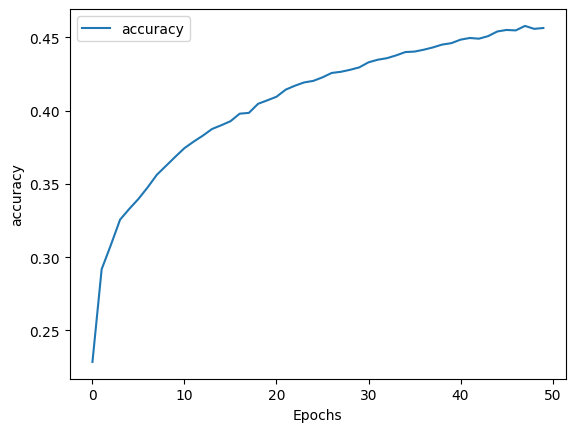

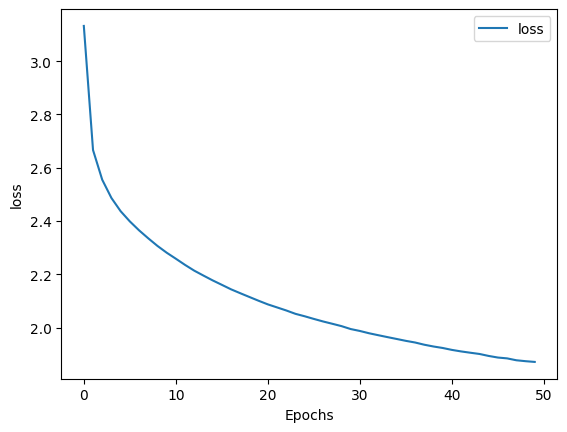

In [129]:
# Plot utility
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

# Plot the accuracy and results
plot_graphs(history_hi_char, "accuracy")
plot_graphs(history_hi_char, "loss")

In [132]:
#save the model
model_hi_char.save('hi_char_prediction')

INFO:tensorflow:Assets written to: hi_char_prediction\assets


INFO:tensorflow:Assets written to: hi_char_prediction\assets


In [133]:
#load and predict the next word
loaded_hi_char_model = tf.keras.models.load_model('hi_char_prediction')

**Next char prediction**

In [135]:
#predict the next 10 chars
test_text = "इसलि"
test_tokens = []

for x in test_text:                                   
  test_tokens.append(hi_char_to_index[x])

test_tokens = pad_sequences([test_tokens],maxlen=hi_max_len-1,padding='pre')  

for i in range(10):
  probabilities = loaded_hi_char_model.predict(test_tokens)
  predicted = np.argmax(probabilities,axis = -1)[0]
  output_char = hi_index_to_char[predicted]
  test_text = test_text + output_char

  test_tokens = np.append(test_tokens, [[predicted]], axis=1)
  test_tokens = test_tokens[:,1:]

print(test_text)

1/1 [==============================] - 0s 33ms/step
इसलिए कहा है।।
